# Getting the Carbonyl Region, Not the Whole Spectrum
### 2.2 — Indexing, Slicing, and Selecting Spectral Regions

Almost no analysis uses the whole spectrum. You want the carbonyl stretch around
1715 cm⁻¹, the analyte band, a quiet stretch of baseline — a *region of interest*.
The skill is asking for a region by its **chemistry** (a wavenumber window), not by
counting array positions you'd have to recount the moment the axis changes.

> **One idea to hold onto:** select a region by **value** with a boolean mask —
> `(wn >= 1680) & (wn <= 1760)` asks for the carbonyl window directly, and keeps
> working even if the axis spacing or length changes.

**By the end of this notebook you will be able to:**

1. Grab single points and contiguous slices of a spectrum.
2. Select a wavenumber region with a boolean mask.
3. Find the peak within a region and exclude a detector gap.

## 1. A spectrum to work on

An IR-style spectrum on a wavenumber axis, with a carbonyl band near 1715 cm⁻¹ and
an aromatic C=C band near 1600 cm⁻¹.

In [3]:
import numpy as np

wn = np.linspace(1000, 2000, 501)   # wavenumber axis (cm^-1), 2 cm^-1 spacing

def band(center, height, width):
    return height * np.exp(-((wn - center) ** 2) / (2 * width ** 2))

absorbance = band(1715, 0.80, 12) + band(1600, 0.45, 18) + 0.02  # + tiny offset

print("points:", wn.size, "| axis:", wn.min(), "-", wn.max(), "cm^-1")

points: 501 | axis: 1000.0 - 2000.0 cm^-1


## 2. Single points and contiguous slices

Indexing pulls one value by position; slicing pulls a contiguous run. `[0]` is the
first point, `[-1]` the last.

In [4]:
print("first point :", wn[0], "cm^-1 ->", round(absorbance[0], 3), "AU")
print("last point  :", wn[-1], "cm^-1 ->", round(absorbance[-1], 3), "AU")

# A contiguous slice by position [start:stop] -- but position is fragile:
# if the axis spacing changed, 100:160 would point somewhere else entirely.
chunk = absorbance[100:160]
print("slice 100:160 has", chunk.size, "points")

first point : 1000.0 cm^-1 -> 0.02 AU
last point  : 2000.0 cm^-1 -> 0.02 AU
slice 100:160 has 60 points


Slicing by position works, but those index numbers are tied to *this* exact axis.
The robust way to ask for chemistry is to select by value.

## 3. Select a region by value (the workhorse)

A boolean mask is a `True`/`False` array the same length as the axis. Indexing with
it keeps only the points where it's `True`. Here we ask for the carbonyl window.

In [5]:
# Build the mask from the chemistry: 1680-1760 cm^-1 brackets the carbonyl band.
carbonyl_mask = (wn >= 1680) & (wn <= 1760)

carbonyl_wn = wn[carbonyl_mask]            # the wavenumbers in the window
carbonyl_abs = absorbance[carbonyl_mask]   # the absorbances there

print("carbonyl window:", carbonyl_wn.min(), "-", carbonyl_wn.max(), "cm^-1")
print("points in window:", carbonyl_abs.size)

carbonyl window: 1680.0 - 1760.0 cm^-1
points in window: 41


The mask asked for the region in the units a chemist thinks in. Change the axis to
1 cm⁻¹ spacing tomorrow and this exact line still selects the carbonyl band — no
index recounting.

## 4. Find the peak within the region

`argmax` gives the position of the maximum *within the slice we selected*; we look
the wavenumber back up to report the band position and height.

In [6]:
i_peak = np.argmax(carbonyl_abs)           # index of the max within the window
peak_wn = carbonyl_wn[i_peak]
peak_height = carbonyl_abs[i_peak]

print("carbonyl peak at:", round(peak_wn, 1), "cm^-1")
print("peak absorbance :", round(peak_height, 3), "AU")

carbonyl peak at: 1714.0 cm^-1
peak absorbance : 0.817 AU


## 5. Exclude a detector gap

Sometimes a region is unusable — a detector gap, a blocked window, a saturated
stretch. You exclude it by *negating* a mask with `~`, keeping everything else.

In [7]:
# Suppose 1450-1480 cm^-1 is a known dead region we must not analyze.
gap = (wn >= 1450) & (wn <= 1480)
usable = ~gap                              # ~ flips True/False: keep everything else

print("total points :", wn.size)
print("points in gap:", gap.sum())
print("usable points:", usable.sum())

# Work only with the usable part of the spectrum.
wn_usable = wn[usable]
absorbance_usable = absorbance[usable]

total points : 501
points in gap: 16
usable points: 485


## 6. See the region in context

Plotting the full spectrum with the carbonyl window shaded shows exactly what the
mask selected — the same habit you met in 2.5.

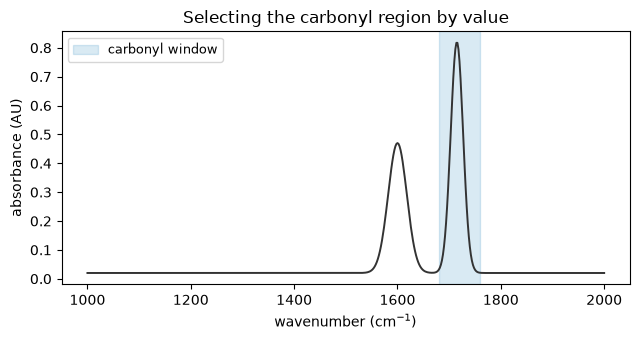

In [8]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.5, 3.5))
ax.plot(wn, absorbance, color="#333333", lw=1.4)
ax.axvspan(1680, 1760, color="#0072B2", alpha=0.15, label="carbonyl window")
ax.set_xlabel("wavenumber (cm$^{-1}$)")
ax.set_ylabel("absorbance (AU)")
ax.set_title("Selecting the carbonyl region by value")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Key Takeaways

- Index by position for single points; **slice** for contiguous runs.
- Select a region by **value** with a boolean mask — it asks for the chemistry and
  survives axis changes.
- `argmax` on a selected region gives the peak position *within* that region.
- Negate a mask with `~` to **exclude** a detector gap and keep the rest.

## Practical Checklist

- [ ] Prefer value-based masks over hard-coded index numbers for regions.
- [ ] Combine conditions with `&` (and) / `|` (or), each in parentheses.
- [ ] When reporting a peak in a window, find it with `argmax` on the masked data.
- [ ] Exclude dead/saturated regions explicitly rather than silently averaging them in.

## Common Mistakes

- Hard-coding index ranges that break when the axis spacing or length changes.
- Forgetting parentheses around each condition: write `(a) & (b)`, not `a & b`.
- Using Python `and`/`or` on arrays (they error) instead of `&`/`|`.

## Next Lesson

**2.3 — pandas DataFrames for Sample Tables.** A spectrum is one measurement; next
we keep many measurements together with the metadata that gives them meaning.